<a href="https://colab.research.google.com/github/Sherzod19s/BUSI2045---Data-Analytics-for-Business-Decision-Making/blob/main/week_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Comparing Groups: Continuous Variables

In [ ]:
grad2 = pd.read_csv('grad2.csv')

In [ ]:
grad2.head()

,Level,Salary,Faculty
0,Undergrad,18440,busi
1,Undergrad,18366,busi
2,Undergrad,20061,non-busi
3,Tpg,24870,non-busi
4,Undergrad,18435,non-busi


In [ ]:
grad2['Salary'].mean()

np.float64(22355.107526881722)

In [ ]:
a = grad2.groupby('Level')['Salary'].mean().reset_index()
abc = round(a,1)
abc

,Level,Salary
0,Rpg,29850.9
1,Tpg,24430.3
2,Undergrad,20542.7


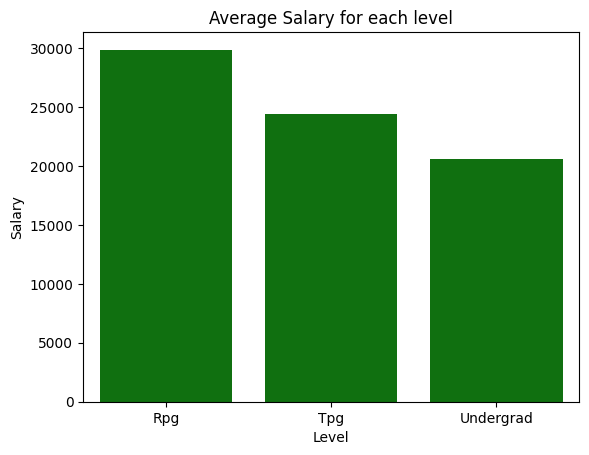

In [ ]:
sns.barplot(data=a, x='Level', y='Salary', color='green')
plt.title('Average Salary for each level')
plt.show()

In [ ]:
grad2.groupby(['Level', 'Faculty'])['Salary'].mean().round(1)

Level      Faculty 
Rpg        busi        30387.7
           non-busi    29505.9
Tpg        busi        24603.6
           non-busi    24332.8
Undergrad  busi        20625.4
           non-busi    20507.6
Name: Salary, dtype: float64

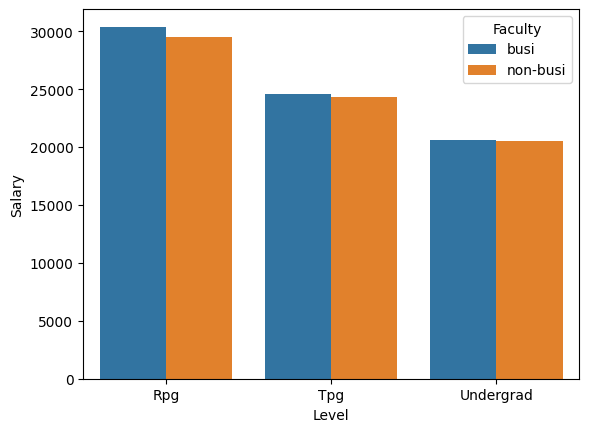

In [ ]:
mean_salaries = grad2.groupby(['Level', 'Faculty'])['Salary'].mean().reset_index()
sns.barplot(data=mean_salaries, x='Level', y='Salary', hue='Faculty')
plt.show()

## For Loop

In [ ]:
for i in range(5):
  print(i)

0
1
2
3
4


In [ ]:
x = [0,1,2,34,10,500]
for i in x:
  print(i*2+1)

1
3
5
69
21
1001


In [ ]:
grad2['Level'].unique()

array(['Undergrad', 'Tpg', 'Rpg'], dtype=object)

In [ ]:
for i in grad2['Level'].unique():
  print(i)
  print(grad2[grad2['Level']==i]['Salary'].mean().round())

Undergrad
20543.0
Tpg
24430.0
Rpg
29851.0


## Test Group Means: T-test

In [ ]:
grad2.groupby('Faculty')['Salary'].mean().reset_index().round()   #sample mean

,Faculty,Salary
0,busi,22795.0
1,non-busi,22146.0


In [ ]:
from scipy import stats
t_stat, p_val = stats.ttest_ind(grad2[grad2['Faculty']=='busi']['Salary'],grad2[grad2['Faculty']=='non-busi']['Salary'])
print("t_statistic: ",t_stat)
print("p-value: ",p_val*100)

t_statistic:  1.6576901651740636
p-value:  9.851205133224989


In [ ]:
group1 = grad2[grad2['Faculty']=='busi']['Salary']
group2 = grad2[grad2['Faculty']=='non-busi']['Salary']

In [ ]:
from scipy import stats
t_stat, p_val = stats.ttest_ind(group1,group2)
print("t_statistic: ",t_stat)
print("p-value: ",p_val*100)

t_statistic:  1.6576901651740636
p-value:  9.851205133224989


In [ ]:
#one sample t test
t_stat, p_val = stats.ttest_1samp(grad2['Salary'], 0)
print(t_stat)
print(p_val)
alpha = 0.05
if p_val < alpha:
    print(f"Reject H₀: Sample mean is significantly different from {t_stat}")
else:
    print(f"Fail to reject H₀: Sample mean is NOT significantly different from {t_stat}")

121.6669186249464
4.0236437542802315e-243
Reject H₀: Sample mean is significantly different from 121.6669186249464


In [ ]:
#one sample t test
t_stat, p_val = stats.ttest_1samp(grad2['Salary'], 22000)
print(t_stat)
print(p_val)
alpha = 0.05
if p_val < alpha:
    print(f"Reject H₀: Sample mean is significantly different from {t_stat}")
else:
    print(f"Fail to reject H₀: Sample mean is NOT significantly different from {t_stat}")

1.9326607364456292
0.054293655500596456
Fail to reject H₀: Sample mean is NOT significantly different from 1.9326607364456292


## ANOVA

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
model = ols('Salary ~ Level', data=grad2).fit()
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)

             df        sum_sq       mean_sq           F         PR(>F)
Level       2.0  2.209816e+09  1.104908e+09  746.132308  4.829831e-112
Residual  276.0  4.087138e+08  1.480847e+06         NaN            NaN


In [ ]:
model = ols('Salary ~ Faculty', data=grad2).fit()
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)

             df        sum_sq       mean_sq         F    PR(>F)
Faculty     1.0  2.572156e+07  2.572156e+07  2.747937  0.098512
Residual  277.0  2.592808e+09  9.360318e+06       NaN       NaN


### One-way

### Two-way

In [ ]:
model = ols('Salary ~ Level+Faculty', data=grad2).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                sum_sq     df           F         PR(>F)
Level     2.187316e+09    2.0  741.705004  1.600388e-111
Faculty   3.221231e+06    1.0    2.184598   1.405418e-01
Residual  4.054926e+08  275.0         NaN            NaN


In [ ]:
model = ols('Salary ~ Level:Faculty', data=grad2).fit()
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)

                  df        sum_sq       mean_sq           F         PR(>F)
Level:Faculty    5.0  2.215870e+09  4.431739e+08  300.467942  9.691055e-109
Residual       273.0  4.026602e+08  1.474946e+06         NaN            NaN


In [ ]:
model = ols('Salary ~ Level+Faculty+Level:Faculty', data=grad2).fit()
anova_table = sm.stats.anova_lm(model, typ=3)
print(anova_table)

                     sum_sq     df            F         PR(>F)
Intercept      8.310693e+09    1.0  5634.575177  2.707050e-184
Level          8.613309e+08    2.0   291.987330   1.534872e-68
Faculty        4.259830e+06    1.0     2.888127   9.037371e-02
Level:Faculty  2.832416e+06    2.0     0.960176   3.841144e-01
Residual       4.026602e+08  273.0          NaN            NaN


# Exercise

In [ ]:
ecomm = pd.read_csv('ecomm.csv')

ecomm

,Unnamed: 0,dateTime,country,city,region,screenRed,surveyType,purposeProductInfo,purposeBuyFromSite,purposeComparePricing,...,behavPageviews,behavHomePage,behavDetailProdA,behavDetailProdB,behavDetailProdC,behavAnySolution,behavAnySale,behavCart,behavConversion,pageViewInt
0,1,7/25/2014 14:10,United States,Monroe,LA,1280x1024,At Exit,Products,NaN,NaN,...,4 to 6,1,1,0,0,0,0,0,0,4
1,2,7/25/2014 15:01,United States,Ambler,PA,1280x800,At Exit,NaN,Buy from this site,Compare pricing,...,1,0,0,0,0,0,0,0,0,1
2,3,7/25/2014 15:15,United States,Beaumont,TX,768x1024,At Exit,NaN,NaN,Compare pricing,...,10+,0,0,0,0,1,1,0,0,10
3,4,7/25/2014 17:05,United States,Cedar City,UT,1280x960,At Exit,Products,NaN,NaN,...,10+,0,1,1,0,1,0,0,0,10
4,5,7/26/2014 0:27,United States,Bullhead City,AZ,1138x640,At Exit,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1588,1589,9/11/2014 11:16,United States,Albany,NY,1280x1024,At Arrival and Exit,Products,NaN,Compare pricing,...,10+,1,1,1,0,0,0,0,0,10
1589,1590,9/11/2014 11:18,United States,Grafton,OH,768x1024,At Arrival Only,Products,NaN,NaN,...,4 to 6,1,0,0,1,0,0,0,0,4
1590,1591,9/11/2014 11:33,United States,Lansing,MI,1680x1050,At Arrival and Exit,Products,NaN,NaN,...,10+,1,0,0,0,1,0,0,0,10
1591,1592,9/11/2014 11:42,United States,Saint Charles,MO,1366x768,At Arrival and Exit,NaN,NaN,NaN,...,4 to 6,0,0,1,0,0,0,0,0,4


## 1a)

In [ ]:
ecomm.columns

Index(['Unnamed: 0', 'dateTime', 'country', 'city', 'region', 'screenRed',
       'surveyType', 'purposeProductInfo', 'purposeBuyFromSite',
       'purposeComparePricing', 'purposeInfoAndResources',
       'purposeInfoOnOrder', 'purposeOther', 'taskFindWhatLookingFor',
       'concernShippingCost', 'concernDeliverySpeed', 'concernWarranties',
       'concernEaseToReturnProduct', 'concernProductSafety',
       'concernRightForMyChild', 'concernProductQuality',
       'concernProductEffectiveness', 'concernOther', 'concernNone',
       'intentWasPlanningToBuy', 'profile', 'whenSiteUsed', 'purchasedBefore',
       'purchasedWhen', 'productKnewWhatWanted', 'productSiteHasWhatWanted',
       'purchaseExpectInNextMonth', 'siteFirstHeardAbout', 'age', 'gender',
       'behavNumVisits', 'behavReferral', 'behavPageviews', 'behavHomePage',
       'behavDetailProdA', 'behavDetailProdB', 'behavDetailProdC',
       'behavAnySolution', 'behavAnySale', 'behavCart', 'behavConversion',
       'pageView

In [ ]:
ecomm['pageViewInt'].unique()

array([ 4,  1, 10,  7,  2,  0])

In [ ]:
ecomm.groupby('profile')['pageViewInt'].mean().reset_index()

,profile,pageViewInt
0,0,2.000000
1,Friend/family friend,5.739130
2,Health Professional,5.209386
3,Other,4.388060
4,Parent,6.280928
5,Person with [condition A],5.730769
6,Relative,5.747664
7,Teacher,5.461883


In [ ]:
ecomm.groupby('profile')['pageViewInt'].median().reset_index()

,profile,pageViewInt
0,0,2.0
1,Friend/family friend,7.0
2,Health Professional,4.0
3,Other,4.0
4,Parent,7.0
5,Person with [condition A],4.0
6,Relative,4.0
7,Teacher,4.0


## 1b)

In [ ]:
for i in ecomm.groupby('profile')['pageViewInt'].mean():
  print(i)

2.0
5.739130434782608
5.209386281588448
4.388059701492537
6.280927835051546
5.730769230769231
5.747663551401869
5.461883408071749


In [ ]:
for i in ecomm['profile'].unique():
  print(i)
  print('- Mean is', ecomm[ecomm['profile']==i]['pageViewInt'].mean())
  print('- Median is', ecomm[ecomm['profile']==i]['pageViewInt'].median())

Parent
- Mean is 6.280927835051546
- Median is 7.0
Person with [condition A]
- Mean is 5.730769230769231
- Median is 4.0
Teacher
- Mean is 5.461883408071749
- Median is 4.0
Health Professional
- Mean is 5.209386281588448
- Median is 4.0
Other
- Mean is 4.388059701492537
- Median is 4.0
Relative
- Mean is 5.747663551401869
- Median is 4.0
Friend/family friend
- Mean is 5.739130434782608
- Median is 7.0
0
- Mean is 2.0
- Median is 2.0


## 2a)

## 2b)

## 2c)